# Exercise 4 — Discrete-event simulation of a blocking system

m=10 service units, no waiting room, offered traffic A = lambda*s = 8, 10 x 10,000 customers.
Verified against Erlang's B-formula  B = (A^m/m!) / sum_{i=0}^m A^i/i!.

In [1]:
%matplotlib inline
import heapq
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as tdist

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)

M, MEAN_SERVICE, MEAN_IA = 10, 8.0, 1.0
A = MEAN_SERVICE / MEAN_IA
N_CUST, N_REPS = 10_000, 10


def erlang_b(A, m):
    B = 1.0
    for i in range(1, m + 1):
        B = A * B / (i + A * B)
    return B


B_EXACT = erlang_b(A, M)


def simulate_loss_system(n, m, interarrival, service, rng):
    busy = []; blocked = 0; t = 0.0
    for _ in range(n):
        t += interarrival(rng)
        while busy and busy[0] <= t:
            heapq.heappop(busy)
        if len(busy) < m:
            heapq.heappush(busy, t + service(rng))
        else:
            blocked += 1
    return blocked / n


def run_experiment(name, interarrival, service, rng):
    fracs = np.array([simulate_loss_system(N_CUST, M, interarrival, service, rng)
                      for _ in range(N_REPS)])
    mean = fracs.mean()
    half = tdist.ppf(0.975, N_REPS - 1) * fracs.std(ddof=1) / np.sqrt(N_REPS)
    print(f"{name:32s} blocked = {mean:.4f}  95% CI [{mean-half:.4f}, {mean+half:.4f}]")
    return dict(name=name, mean=mean, lo=mean - half, hi=mean + half)


print(f"Erlang B (A={A}, m={M}) = {B_EXACT:.5f}")

Erlang B (A=8.0, m=10) = 0.12166


In [2]:
def ia_poisson(rng):  return rng.exponential(MEAN_IA)
def ia_erlang(rng, k=2):  return rng.gamma(k, MEAN_IA / k)
def make_hyperexp_ia(p1, l1, l2):
    return lambda rng: rng.exponential(1 / l1) if rng.random() < p1 else rng.exponential(1 / l2)

def sv_exponential(rng):  return rng.exponential(MEAN_SERVICE)
def sv_constant(rng):     return MEAN_SERVICE
def make_pareto_service(k):
    beta = MEAN_SERVICE * (k - 1) / k
    return lambda rng: beta * (1.0 - rng.random()) ** (-1.0 / k)
def sv_gamma(rng, shape=2.0):  return rng.gamma(shape, MEAN_SERVICE / shape)

## Part 1 — Poisson arrivals, exponential service

In [3]:
results = []
results.append(run_experiment("Part1: Poisson + Exp", ia_poisson, sv_exponential, rng))
print(f"analytical Erlang B = {B_EXACT:.4f}")

Part1: Poisson + Exp             blocked = 0.1228  95% CI [0.1189, 0.1268]
analytical Erlang B = 0.1217


## Part 2 — Renewal arrivals (Erlang and hyperexponential), exponential service

In [4]:
hyperexp_ia = make_hyperexp_ia(0.8, 0.8333, 5.0)
results.append(run_experiment("Part2a: Erlang arr + Exp", ia_erlang, sv_exponential, rng))
results.append(run_experiment("Part2b: Hyperexp arr + Exp", hyperexp_ia, sv_exponential, rng))

Part2a: Erlang arr + Exp         blocked = 0.0920  95% CI [0.0881, 0.0959]


Part2b: Hyperexp arr + Exp       blocked = 0.1360  95% CI [0.1321, 0.1400]


## Part 3 — Poisson arrivals, different service distributions (mean 8)

In [5]:
results.append(run_experiment("Part3a: Constant", ia_poisson, sv_constant, rng))
results.append(run_experiment("Part3b: Pareto k=2.05", ia_poisson, make_pareto_service(2.05), rng))
results.append(run_experiment("Part3b: Pareto k=1.05", ia_poisson, make_pareto_service(1.05), rng))
results.append(run_experiment("Part3c: Gamma(2)", ia_poisson, sv_gamma, rng))
print(f"analytical Erlang B = {B_EXACT:.4f}")

Part3a: Constant                 blocked = 0.1214  95% CI [0.1192, 0.1237]


Part3b: Pareto k=2.05            blocked = 0.1225  95% CI [0.1168, 0.1283]


Part3b: Pareto k=1.05            blocked = 0.0008  95% CI [0.0002, 0.0013]


Part3c: Gamma(2)                 blocked = 0.1224  95% CI [0.1192, 0.1255]
analytical Erlang B = 0.1217


## Part 4 — Compare confidence intervals

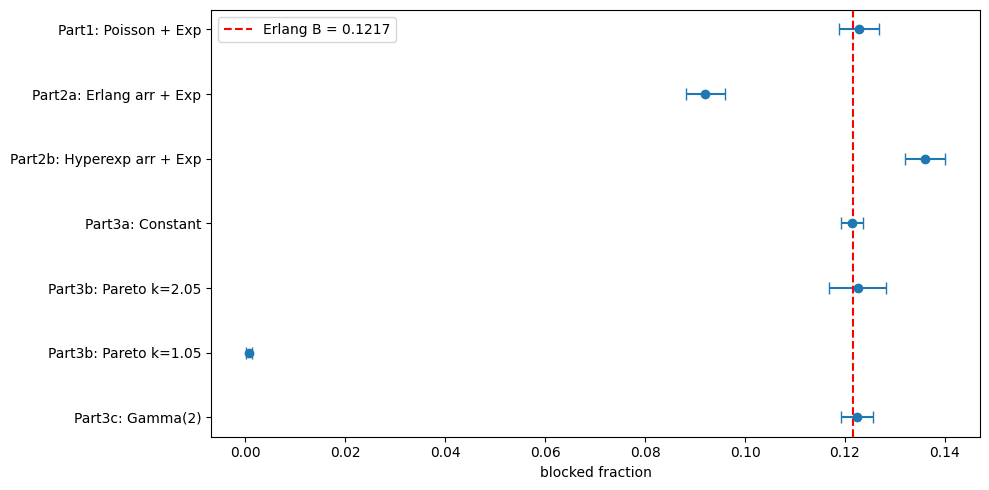

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, r in enumerate(results):
    ax.errorbar(r["mean"], i, xerr=[[r["mean"] - r["lo"]], [r["hi"] - r["mean"]]],
                fmt="o", capsize=4, color="C0")
ax.axvline(B_EXACT, color="red", ls="--", label=f"Erlang B = {B_EXACT:.4f}")
ax.set_yticks(range(len(results))); ax.set_yticklabels([r["name"] for r in results])
ax.set_xlabel("blocked fraction"); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()

Poisson-arrival cases (Parts 1, 3) match Erlang B regardless of the service distribution
(insensitivity) — except Pareto k=1.05, whose infinite-variance tail prevents the mean service time (8)
from being realized in 10,000 samples (realized mean ~2.6-9.8), so the effective load and blocking
collapse. Renewal arrivals (Part 2) move blocking away from B: Erlang (regular) arrivals lower it,
hyperexponential (bursty) arrivals raise it. Heavy-tailed inputs give wider CIs.